In [1]:
# 1. Install yfinance directly inside the Colab notebook
!pip install yfinance

# 2. Import packages
import pandas as pd
import numpy as np
import yfinance as yf

# 3. Define the Bulletproof Phase 1 Data Pipeline
def fetch_and_preprocess_data(ticker: str = "^GSPC", start_date: str = "2000-01-01", end_date: str = "2026-06-01") -> pd.DataFrame:
    print(f"Fetching historical data for {ticker}...")

    # Fetch data - auto_adjust=False ensures we explicitly get Adj Close if available
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

    # Fix potential MultiIndex columns that newer yfinance versions generate
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    # Standardize column names to lowercase to prevent KeyErrors
    df.columns = [str(col).lower() for col in df.columns]

    # Look for adj close or close fallback
    target_col = 'adj close' if 'adj close' in df.columns else 'close'

    # Clean dataframe structure
    df_clean = df[[target_col]].copy()
    df_clean.columns = ['adj_close']

    # Calculate raw returns and magnitude (absolute returns)
    df_clean['raw_return'] = df_clean['adj_close'].pct_change()
    df_clean['abs_return'] = df_clean['raw_return'].abs()

    return df_clean.dropna()

# 4. Run it
market_data = fetch_and_preprocess_data()
market_data.head()

Fetching historical data for ^GSPC...


[*********************100%***********************]  1 of 1 completed


,adj_close,raw_return,abs_return
Date,,,
2000-01-04,1399.420044,-0.038345,0.038345
2000-01-05,1402.109985,0.001922,0.001922
2000-01-06,1403.449951,0.000956,0.000956
2000-01-07,1441.469971,0.027090,0.027090
2000-01-10,1457.599976,0.011190,0.011190


In [2]:
def calculate_streaks_and_probabilities(df: pd.DataFrame, max_streak: int = 5):
    """
    Calculates consecutive day streaks and computes the conditional probability
    of the next day being positive based on those streaks.
    """
    df = df.copy()

    # 1. Define direction (1 for Up, 0 for Down/Flat)
    df['direction'] = (df['raw_return'] > 0).astype(int)

    # 2. Vectorized Streak Counter
    streak_counts = []
    current_streak = 0

    for i in range(len(df)):
        if i == 0:
            streak_counts.append(0)
            continue

        prev_direction = df['direction'].iloc[i-1]

        # If previous day was Up (+1), increment positive streak. If Down, decrement negative streak.
        if prev_direction == 1:
            current_streak = current_streak + 1 if current_streak > 0 else 1
        else:
            current_streak = current_streak - 1 if current_streak < 0 else -1

        streak_counts.append(current_streak)

    df['prior_streak'] = streak_counts

    # 3. Calculate Overall Base Rate (Unconditional Probability)
    base_rate = df['direction'].mean()
    print(f"Overall Market Base Rate (Historical % of Up Days): {base_rate:.2%}\n")

    # 4. Group by streak length and calculate conditional probability of tomorrow being UP
    streak_analysis = []

    # We look at positive streaks (1 up day, 2 up days... up to max_streak)
    for s in range(1, max_streak + 1):
        if s == max_streak:
            subset = df[df['prior_streak'] >= s]
            label = f"{s}+ Up Days"
        else:
            subset = df[df['prior_streak'] == s]
            label = f"{s} Up Day(s)"

        if len(subset) > 0:
            prob_next_up = subset['direction'].mean()
            streak_analysis.append({
                'Streak Context': label,
                'Sample Size (Days)': len(subset),
                'Prob of Next Day UP': f"{prob_next_up:.2%}"
            })

    return pd.DataFrame(streak_analysis), base_rate

# Run Phase 2
streak_df, market_base_rate = calculate_streaks_and_probabilities(market_data)
streak_df

Overall Market Base Rate (Historical % of Up Days): 53.78%



,Streak Context,Sample Size (Days),Prob of Next Day UP
0,1 Up Day(s),1738,51.84%
1,2 Up Day(s),901,53.27%
2,3 Up Day(s),480,48.96%
3,4 Up Day(s),235,48.94%
4,5+ Up Days,216,47.22%


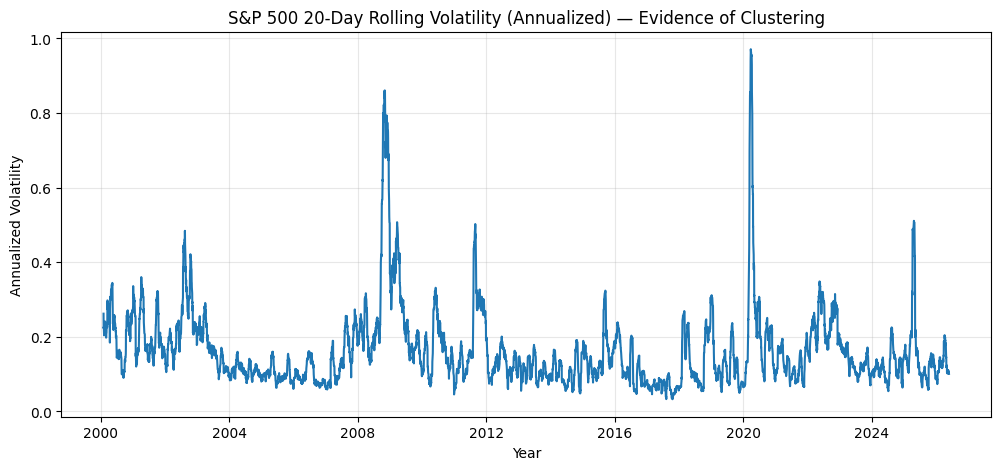


Autocorrelation Comparison Table:
 Lag (Days)  Raw Return ACF (Direction)  Absolute Return ACF (Magnitude)
          1                   -0.100796                         0.287559
          5                   -0.012868                         0.341689
         20                    0.010316                         0.227682


In [3]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def analyze_volatility_and_autocorrelation(df: pd.DataFrame, max_lag: int = 20):
    """
    Computes rolling volatility and contrasts the autocorrelation of
    raw returns vs. absolute returns.
    """
    df = df.copy()

    # 1. Compute 20-day rolling volatility (annualized for clean industry formatting)
    # Multiplying by sqrt(252) converts daily standard deviation to annualized volatility
    df['rolling_vol'] = df['raw_return'].rolling(window=20).std() * np.sqrt(252)

    # Plot rolling volatility over time to visually spot the clusters ("storms")
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df['rolling_vol'], color='#1f77b4', lw=1.5)
    plt.title('S&P 500 20-Day Rolling Volatility (Annualized) — Evidence of Clustering')
    plt.xlabel('Year')
    plt.ylabel('Annualized Volatility')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 2. Compute Autocorrelation Functions (ACF)
    # acf returns coefficients for lag 0, lag 1... up to max_lag. We skip lag 0 (correlation with itself is always 1).
    acf_raw = acf(df['raw_return'], nlags=max_lag, fft=True)[1:]
    acf_abs = acf(df['abs_return'], nlags=max_lag, fft=True)[1:]

    # 3. Create comparison dataframe for printing
    lags = list(range(1, max_lag + 1))
    acf_df = pd.DataFrame({
        'Lag (Days)': lags,
        'Raw Return ACF (Direction)': acf_raw,
        'Absolute Return ACF (Magnitude)': acf_abs
    })

    # Filter to view specific key lags (1 day, 5 days/1 week, 20 days/1 month) for interview discussions
    print("\nAutocorrelation Comparison Table:")
    print(acf_df.iloc[[0, 4, 19]].to_string(index=False))

    return acf_df

# Run Phase 3
acf_data = analyze_volatility_and_autocorrelation(market_data)

/tmp/ipykernel_1269/4010907514.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streak_names, y=streak_probs, ax=axes[0, 0], palette="Blues_d")


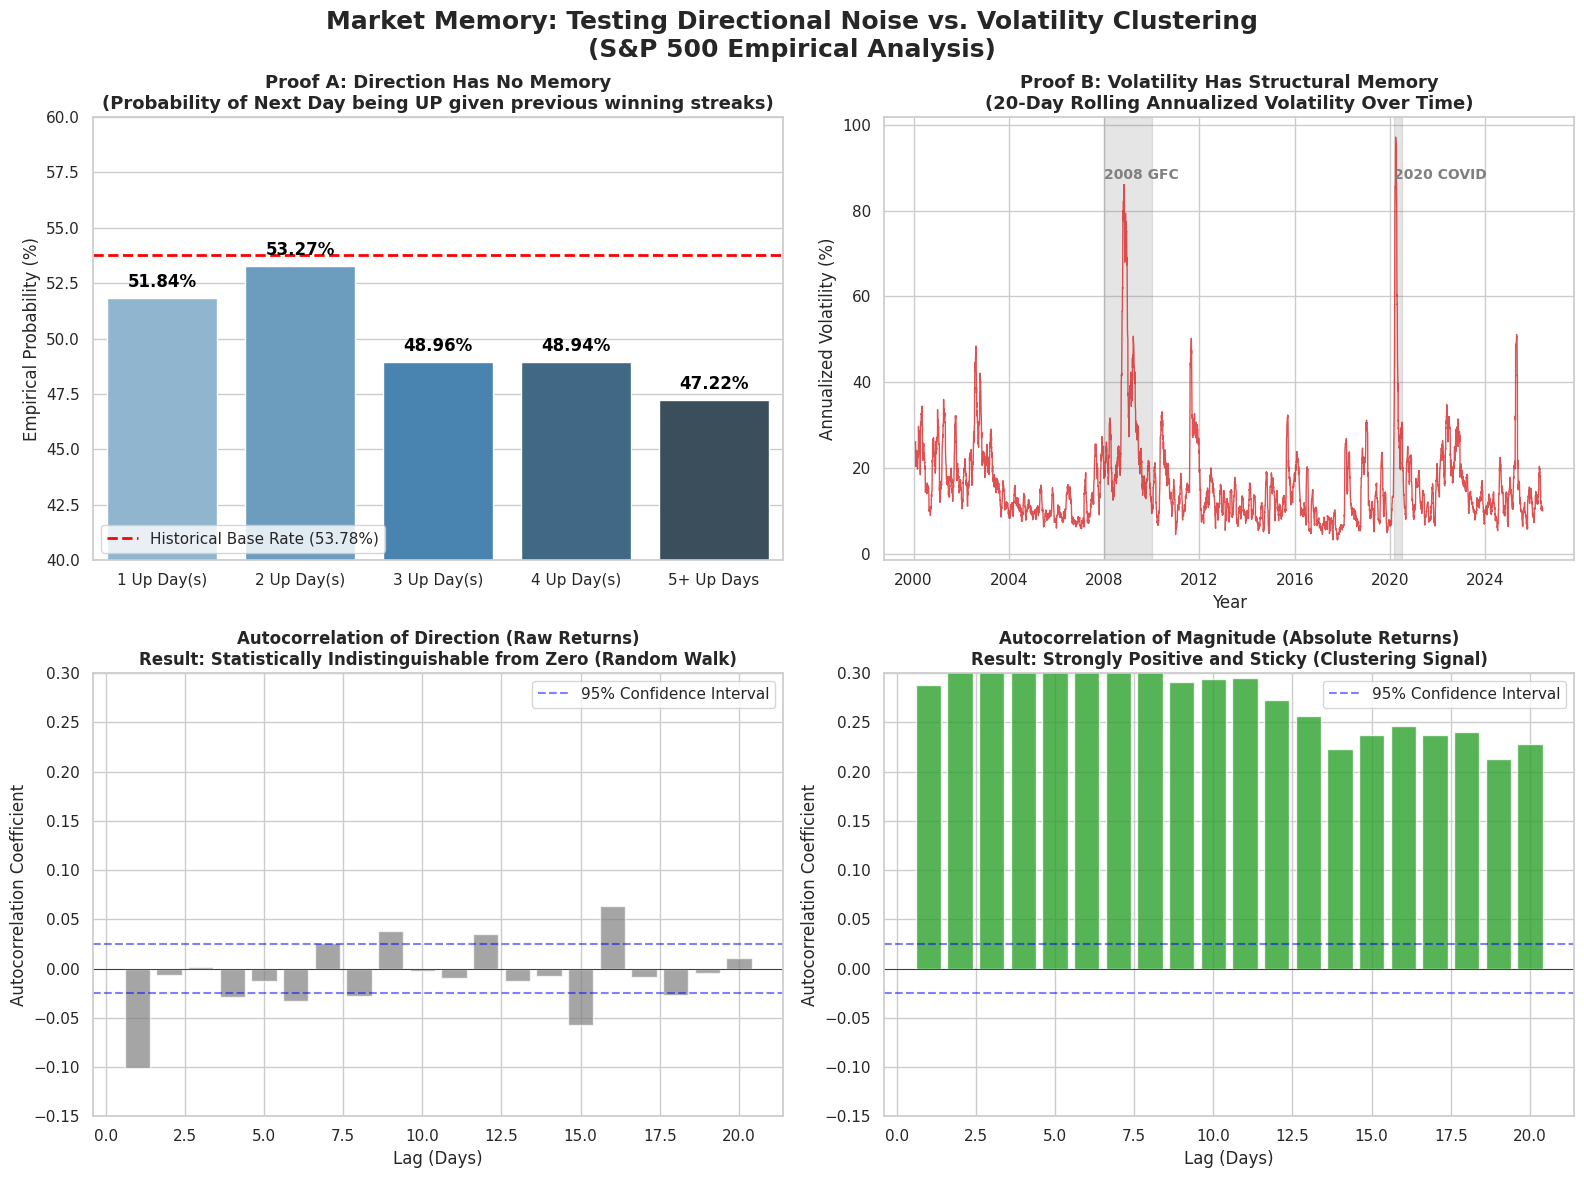

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style for a professional portfolio look
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Market Memory: Testing Directional Noise vs. Volatility Clustering\n(S&P 500 Empirical Analysis)", fontsize=18, fontweight='bold', y=0.98)

# ----------------------------------------------------
# PLOT 1: Proof A - The Streak Myth (Bar Chart)
# ----------------------------------------------------
# Parse out percentages from the previous streak_df strings
streak_names = streak_df['Streak Context'].tolist()
streak_probs = [float(x.replace('%', '')) for x in streak_df['Prob of Next Day UP']]

sns.barplot(x=streak_names, y=streak_probs, ax=axes[0, 0], palette="Blues_d")
axes[0, 0].axhline(market_base_rate * 100, color='red', linestyle='--', linewidth=2, label=f'Historical Base Rate ({market_base_rate*100:.2f}%)')
axes[0, 0].set_title("Proof A: Direction Has No Memory\n(Probability of Next Day being UP given previous winning streaks)", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Empirical Probability (%)")
axes[0, 0].set_ylim(40, 60)
axes[0, 0].legend(loc="lower left")

# Quick metric annotations
for i, p in enumerate(streak_probs):
    axes[0, 0].text(i, p + 0.5, f"{p:.2f}%", ha='center', fontweight='bold', color='black')

# ----------------------------------------------------
# PLOT 2: Proof B - Volatility Storms (Time Series)
# ----------------------------------------------------
# Recalculate rolling vol locally to keep the chart clean
market_data['rolling_vol'] = market_data['raw_return'].rolling(window=20).std() * (252**0.5) * 100

axes[0, 1].plot(market_data.index, market_data['rolling_vol'], color='#d62728', alpha=0.8, lw=1)
axes[0, 1].set_title("Proof B: Volatility Has Structural Memory\n(20-Day Rolling Annualized Volatility Over Time)", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Annualized Volatility (%)")
axes[0, 1].set_xlabel("Year")

# Highlight measurable historical macro clusters
crisis_periods = [
    ("2008 GFC", "2008-01-01", "2009-12-31"),
    ("2020 COVID", "2020-03-01", "2020-06-30")
]
for name, start, end in crisis_periods:
    axes[0, 1].axvspan(pd.to_datetime(start), pd.to_datetime(end), color='gray', alpha=0.2)
    axes[0, 1].text(pd.to_datetime(start), market_data['rolling_vol'].max()*0.9, name, fontsize=10, fontweight='bold', color='gray')

# ----------------------------------------------------
# PLOTS 3 & 4: The Core Autocorrelation Face-off
# ----------------------------------------------------
# Extract lags and coefficients from Phase 3 data
lags = acf_data['Lag (Days)']
acf_raw = acf_data['Raw Return ACF (Direction)']
acf_abs = acf_data['Absolute Return ACF (Magnitude)']

# Plot Raw Returns Autocorrelation (Noise)
axes[1, 0].bar(lags, acf_raw, color='#7f7f7f', alpha=0.7)
axes[1, 0].axhline(0, color='black', linestyle='-', linewidth=0.5)
# Add standard statistical significance bands (95% confidence interval proxy ~ 2/sqrt(N))
conf_interval = 2 / (len(market_data) ** 0.5)
axes[1, 0].axhline(conf_interval, color='blue', linestyle='--', alpha=0.5, label='95% Confidence Interval')
axes[1, 0].axhline(-conf_interval, color='blue', linestyle='--', alpha=0.5)
axes[1, 0].set_title("Autocorrelation of Direction (Raw Returns)\nResult: Statistically Indistinguishable from Zero (Random Walk)", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Autocorrelation Coefficient")
axes[1, 0].set_xlabel("Lag (Days)")
axes[1, 0].set_ylim(-0.15, 0.3)
axes[1, 0].legend()

# Plot Absolute Returns Autocorrelation (Signal / Persistence)
axes[1, 1].bar(lags, acf_abs, color='#2ca02c', alpha=0.8)
axes[1, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].axhline(conf_interval, color='blue', linestyle='--', alpha=0.5, label='95% Confidence Interval')
axes[1, 1].axhline(-conf_interval, color='blue', linestyle='--', alpha=0.5)
axes[1, 1].set_title("Autocorrelation of Magnitude (Absolute Returns)\nResult: Strongly Positive and Sticky (Clustering Signal)", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Autocorrelation Coefficient")
axes[1, 1].set_xlabel("Lag (Days)")
axes[1, 1].set_ylim(-0.15, 0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()